In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# 1. Load the dataset
df_ecommerce = pd.read_csv("Ecommerce_Sales_Prediction_Dataset.csv")

In [3]:
# 2. View the first 5 rows
print("--- First 5 Rows of the Dataset ---")
print(df_ecommerce.head())

--- First 5 Rows of the Dataset ---
         Date Product_Category   Price  Discount Customer_Segment  \
0  01-01-2023           Sports  932.80     35.82       Occasional   
1  02-01-2023             Toys  569.48      3.60          Premium   
2  03-01-2023       Home Decor  699.68      3.56          Premium   
3  04-01-2023             Toys  923.27      0.61          Premium   
4  05-01-2023             Toys  710.17     47.83          Premium   

   Marketing_Spend  Units_Sold  
0          6780.38          32  
1          6807.56          16  
2          3793.91          27  
3          9422.75          29  
4          1756.83          17  


In [4]:
print("\n--- Dataset Shape (Rows, Columns) ---")
print(df_ecommerce.shape)


--- Dataset Shape (Rows, Columns) ---
(1000, 7)


In [5]:
print("\n--- Missing Values Check ---")
print(df_ecommerce.isnull().sum())


--- Missing Values Check ---
Date                0
Product_Category    0
Price               0
Discount            0
Customer_Segment    0
Marketing_Spend     0
Units_Sold          0
dtype: int64


In [6]:
print("\n--- Data Types Check ---")
print(df_ecommerce.info())


--- Data Types Check ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1000 non-null   object 
 1   Product_Category  1000 non-null   object 
 2   Price             1000 non-null   float64
 3   Discount          1000 non-null   float64
 4   Customer_Segment  1000 non-null   object 
 5   Marketing_Spend   1000 non-null   float64
 6   Units_Sold        1000 non-null   int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 54.8+ KB
None


In [7]:
# 1. Get statistical summary of numerical columns
print("--- Statistical Summary ---")
print(df_ecommerce.describe())

--- Statistical Summary ---
             Price     Discount  Marketing_Spend   Units_Sold
count  1000.000000  1000.000000      1000.000000  1000.000000
mean    505.241920    24.919750      4912.830240    29.631000
std     289.791248    14.439951      2840.602656     7.267989
min      14.590000     0.010000       100.300000     5.000000
25%     243.342500    12.995000      2413.020000    24.000000
50%     509.310000    24.965000      4837.245000    30.000000
75%     747.592500    37.562500      7319.675000    34.000000
max     999.420000    49.920000      9995.620000    57.000000


In [8]:
# 2. Feature Engineering: Create 'Total_Sales' column
# Total_Sales = Price * Units_Sold
df_ecommerce['Total_Sales'] = df_ecommerce['Price'] * df_ecommerce['Units_Sold']

In [9]:
# 3. View the updated dataframe with the new column
print("\n--- First 3 Rows with Total_Sales ---")
print(df_ecommerce[['Product_Category', 'Price', 'Units_Sold', 'Total_Sales']].head(3))


--- First 3 Rows with Total_Sales ---
  Product_Category   Price  Units_Sold  Total_Sales
0           Sports  932.80          32     29849.60
1             Toys  569.48          16      9111.68
2       Home Decor  699.68          27     18891.36


Text(0.5, 0, 'Units Sold')

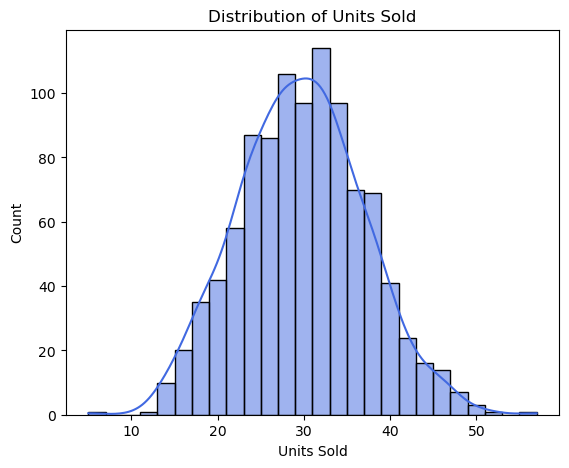

In [10]:
# Create a figure for two subplots
plt.figure(figsize=(14, 5))

# Plot 1: Distribution of Units Sold
plt.subplot(1, 2, 1)
sns.histplot(df_ecommerce['Units_Sold'], kde=True, color='royalblue')
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')




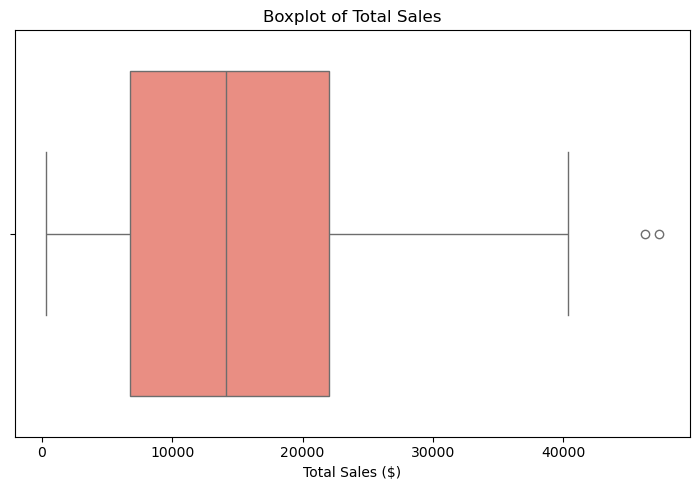

In [11]:
# Plot 2: Boxplot of Total Sales to check for outliers
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 2)
sns.boxplot(x=df_ecommerce['Total_Sales'], color='salmon')
plt.title('Boxplot of Total Sales')
plt.xlabel('Total Sales ($)')

# Show the clean plots
plt.tight_layout()
plt.show()

Total rows before cleaning: 1000
Total rows after cleaning: 998
Number of outliers removed: 2


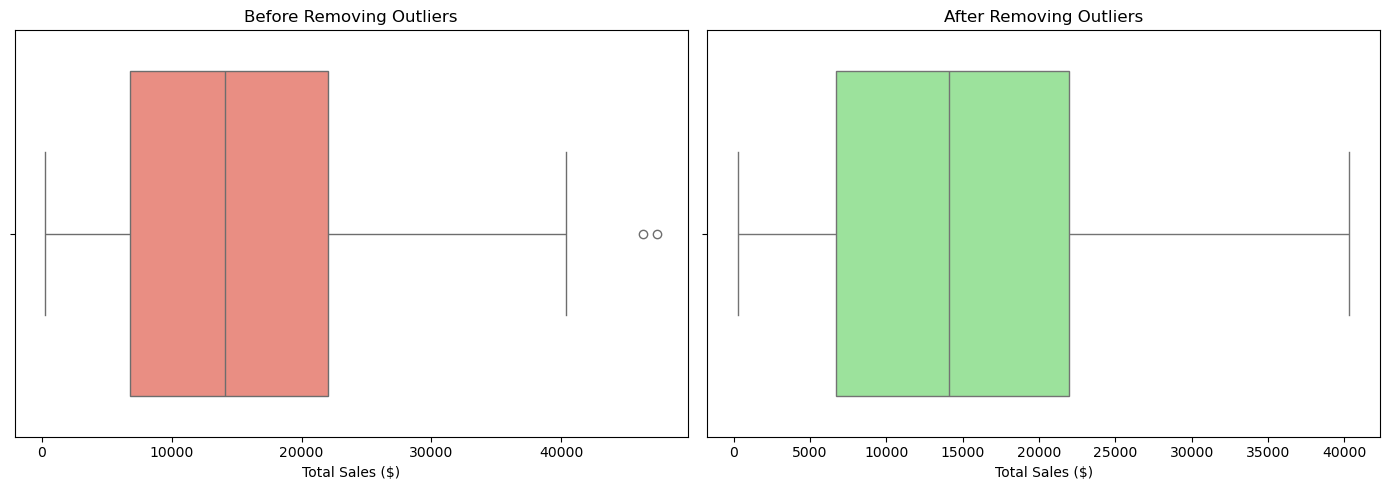

In [12]:


# 1. Calculate Total_Sales feature
df_ecommerce['Total_Sales'] = df_ecommerce['Price'] * df_ecommerce['Units_Sold']

# 2. Compute Interquartile Range (IQR) for Total_Sales
Q1 = df_ecommerce['Total_Sales'].quantile(0.25)
Q3 = df_ecommerce['Total_Sales'].quantile(0.75)
IQR = Q3 - Q1

# Define boundaries for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filter out the outliers to create a cleaned dataframe
df_ecommerce_cleaned = df_ecommerce[(df_ecommerce['Total_Sales'] >= lower_bound) & (df_ecommerce['Total_Sales'] <= upper_bound)]

# Print rows count comparison
print(f"Total rows before cleaning: {len(df_ecommerce)}")
print(f"Total rows after cleaning: {len(df_ecommerce_cleaned)}")
print(f"Number of outliers removed: {len(df_ecommerce) - len(df_ecommerce_cleaned)}")

# 4. Plot Boxplots to visualize the change
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot Before Cleaning
sns.boxplot(x=df_ecommerce['Total_Sales'], ax=axes[0], color='salmon')
axes[0].set_title('Before Removing Outliers')
axes[0].set_xlabel('Total Sales ($)')

# Boxplot After Cleaning
sns.boxplot(x=df_ecommerce_cleaned['Total_Sales'], ax=axes[1], color='lightgreen')
axes[1].set_title('After Removing Outliers')
axes[1].set_xlabel('Total Sales ($)')

plt.tight_layout()
plt.show()



In [13]:
# Select only numeric columns
numeric_cols = df_ecommerce.select_dtypes(include=np.number)

# Calculate and print correlation matrix rounded to 2 decimals
print("--- Correlation Matrix Table ---")
print(numeric_cols.corr().round(2))

--- Correlation Matrix Table ---
                 Price  Discount  Marketing_Spend  Units_Sold  Total_Sales
Price             1.00      0.03            -0.00        0.02         0.90
Discount          0.03      1.00             0.01       -0.03         0.02
Marketing_Spend  -0.00      0.01             1.00        0.01         0.01
Units_Sold        0.02     -0.03             0.01        1.00         0.39
Total_Sales       0.90      0.02             0.01        0.39         1.00


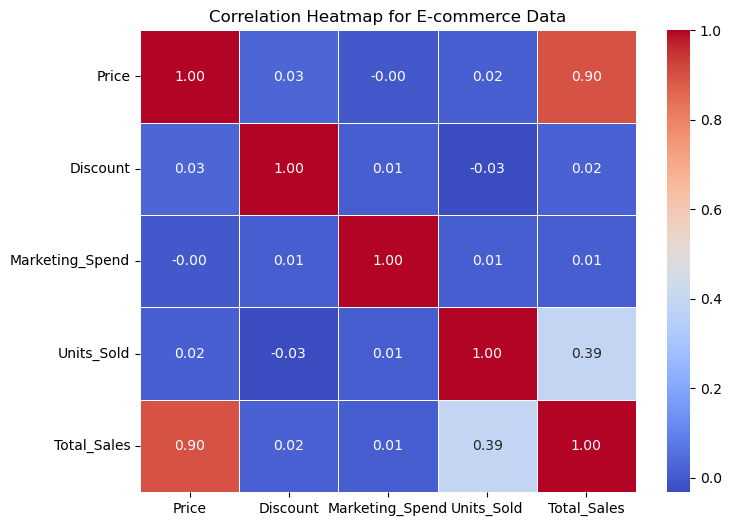

In [14]:
# 1. Select only numeric columns for correlation
numeric_cols = df_ecommerce.select_dtypes(include=np.number)
# 2. Calculate the correlation matrix
corr_matrix = numeric_cols.corr()
# 3. Plot the Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap for E-commerce Data')
plt.show()


C:\Users\asus\AppData\Local\Temp\ipykernel_15560\3459158470.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df_ecommerce, x='Product_Category', y='Units_Sold', estimator=sum, ci=None, palette='viridis')
C:\Users\asus\AppData\Local\Temp\ipykernel_15560\3459158470.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ecommerce, x='Product_Category', y='Units_Sold', estimator=sum, ci=None, palette='viridis')


Text(0, 0.5, 'Total Units Sold')

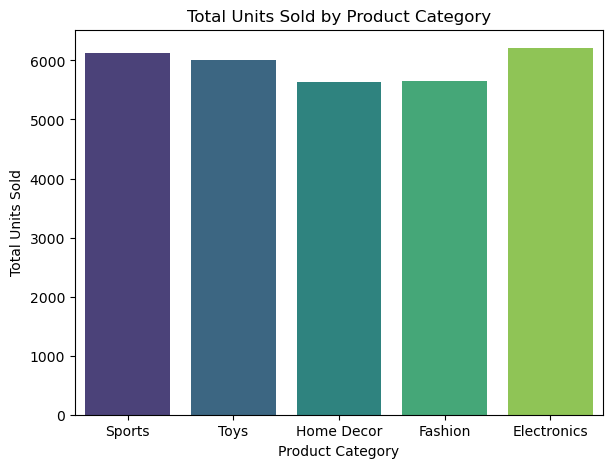

In [15]:
# Create subplots for Product Category and Customer Segment
plt.figure(figsize=(15, 5))

# Plot 1: Total Units Sold by Product Category
plt.subplot(1, 2, 1)
sns.barplot(data=df_ecommerce, x='Product_Category', y='Units_Sold', estimator=sum, ci=None, palette='viridis')
plt.title('Total Units Sold by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Units Sold')


C:\Users\asus\AppData\Local\Temp\ipykernel_15560\2922946668.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_ecommerce, x='Customer_Segment', y='Total_Sales', palette='pastel')


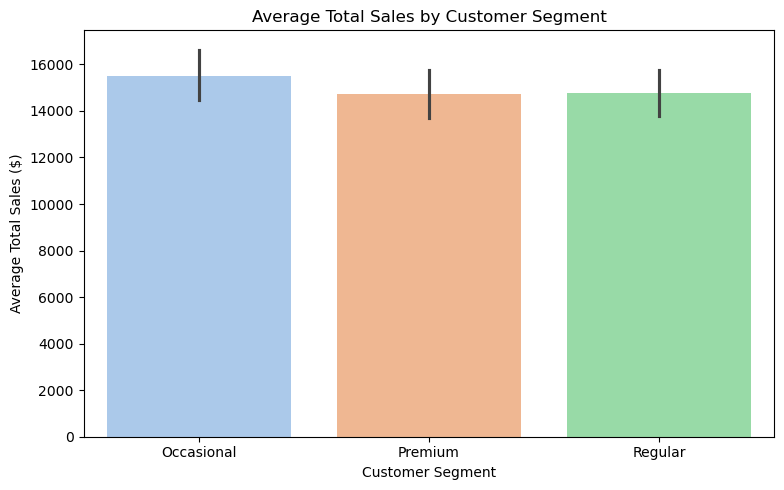

In [16]:
# Plot 2: Average Total Sales by Customer Segment
plt.figure(figsize=(15, 5))
plt.subplot(1, 2, 2)
sns.barplot(data=df_ecommerce, x='Customer_Segment', y='Total_Sales', palette='pastel')
plt.title('Average Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Total Sales ($)')

plt.tight_layout()
plt.show()

In [17]:
# 5. Save the cleaned dataset to a new CSV file
df_ecommerce_cleaned.to_csv("Ecommerce_Sales_Cleaned.csv", index=False)
print("Cleaned dataset successfully saved to 'Ecommerce_Sales_Cleaned.csv'")

Cleaned dataset successfully saved to 'Ecommerce_Sales_Cleaned.csv'
